# 04 — Revenue Analysis
AOV, revenue by channel/device/subcategory, top products, discount impact, repeat purchases.

**Prerequisite:** Run `01_data_generation.ipynb` first.

In [1]:
# Cell 1 — Imports & Connection
import sqlite3, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE_DIR = Path('..').resolve()
DB_PATH  = BASE_DIR / 'data' / 'raw' / 'ecommerce.db'
assert DB_PATH.exists(), 'Run notebook 01 first'
conn = sqlite3.connect(DB_PATH)
print('Connected.')

Connected.


  month  orders   revenue     aov  discounts
2024-01     545 694872.94 1275.00    6775.76
2024-02     519 655374.30 1262.76    7104.81
2024-03     524 678193.01 1294.26    5727.11
2024-04     534 696506.73 1304.32    6896.54
2024-05     508 640947.04 1261.71    6406.06
2024-06     511 674565.67 1320.09    6830.67


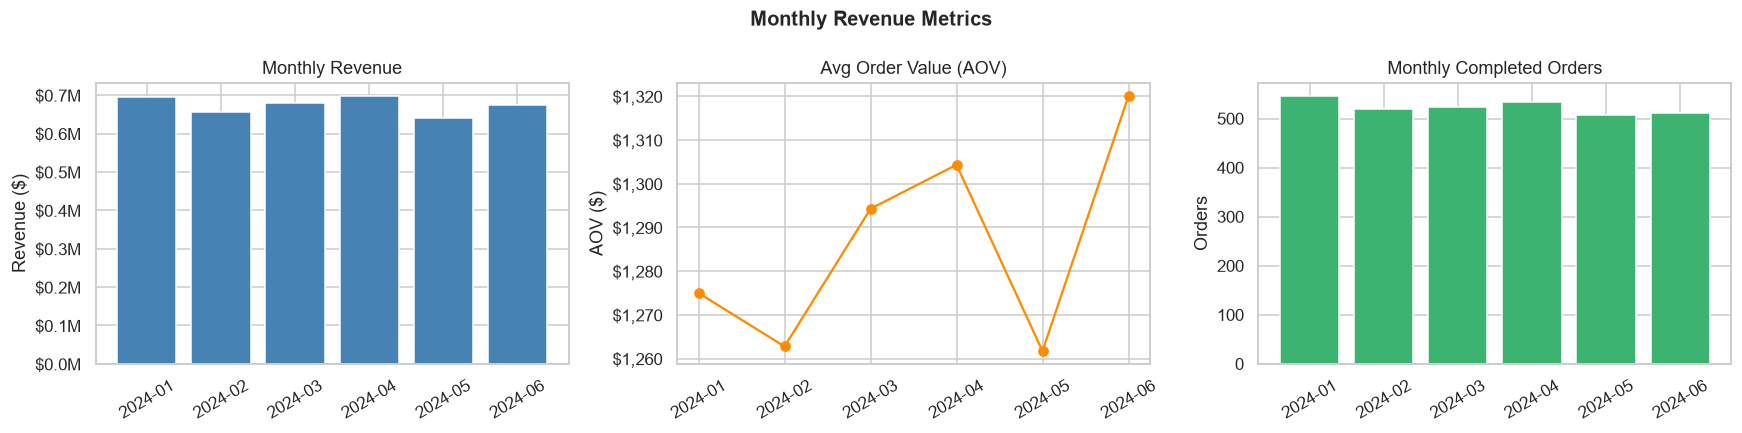

In [2]:
# Cell 2 — Monthly Revenue, Orders & AOV
sql = """
SELECT strftime('%Y-%m', order_date) AS month,
       COUNT(CASE WHEN status='completed' THEN 1 END)                        AS orders,
       ROUND(SUM(CASE WHEN status='completed' THEN total_amount  ELSE 0 END),2) AS revenue,
       ROUND(AVG(CASE WHEN status='completed' THEN total_amount  END),2)        AS aov,
       ROUND(SUM(CASE WHEN status='completed' THEN discount_amount ELSE 0 END),2) AS discounts
FROM orders GROUP BY month ORDER BY month
"""
df_monthly = pd.read_sql(sql, conn)
print(df_monthly.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Monthly Revenue Metrics', fontsize=13, fontweight='bold')

axes[0].bar(df_monthly['month'], df_monthly['revenue'], color='steelblue')
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

axes[1].plot(df_monthly['month'], df_monthly['aov'], color='darkorange', marker='o')
axes[1].set_title('Avg Order Value (AOV)')
axes[1].set_ylabel('AOV ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

axes[2].bar(df_monthly['month'], df_monthly['orders'], color='mediumseagreen')
axes[2].set_title('Monthly Completed Orders')
axes[2].set_ylabel('Orders')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_monthly.png', bbox_inches='tight')
plt.show()

       channel  orders    revenue     aov  revenue_share_pct
organic_search     876 1161853.92 1326.32               28.8
   paid_search     699  866434.42 1239.53               21.4
  social_media     529  677352.56 1280.44               16.8
        direct     388  509024.31 1311.92               12.6
         email     392  497531.10 1269.21               12.3
      referral     257  328263.38 1277.29                8.1


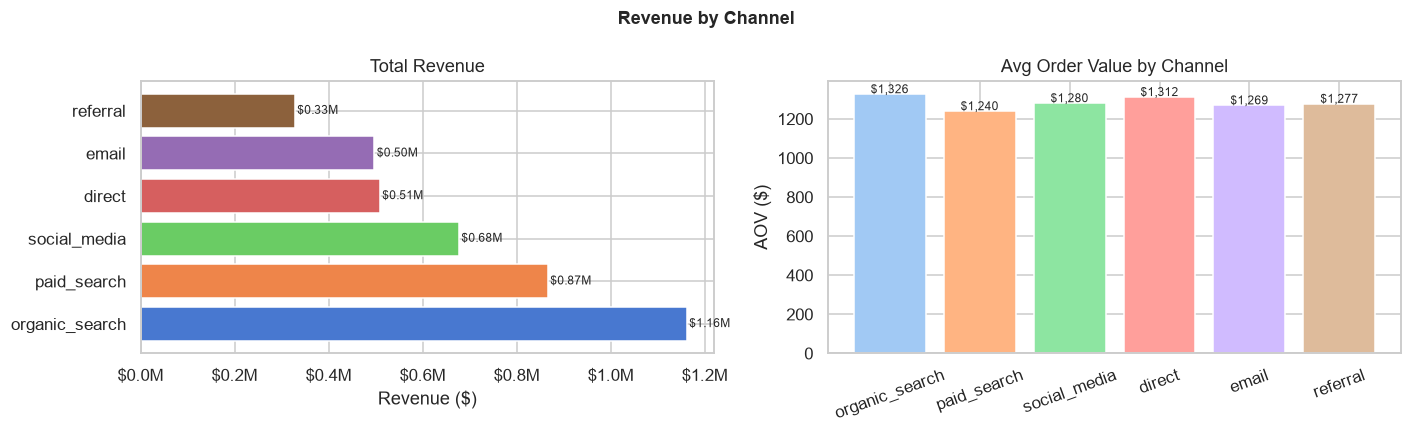

In [3]:
# Cell 3 — Revenue by Acquisition Channel
sql = """
SELECT s.channel,
       COUNT(CASE WHEN o.status='completed' THEN 1 END)                            AS orders,
       ROUND(SUM(CASE WHEN o.status='completed' THEN o.total_amount ELSE 0 END),2) AS revenue,
       ROUND(AVG(CASE WHEN o.status='completed' THEN o.total_amount END),2)        AS aov
FROM orders o JOIN sessions s ON o.session_id=s.session_id
GROUP BY s.channel ORDER BY revenue DESC
"""
df_channel = pd.read_sql(sql, conn)
df_channel['revenue_share_pct'] = (df_channel['revenue'] / df_channel['revenue'].sum() * 100).round(1)
print(df_channel.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Revenue by Channel', fontsize=12, fontweight='bold')

axes[0].barh(df_channel['channel'], df_channel['revenue'],
             color=sns.color_palette('muted', len(df_channel)))
axes[0].set_title('Total Revenue')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
for i, v in enumerate(df_channel['revenue']):
    axes[0].text(v + 5000, i, f'${v/1e6:.2f}M', va='center', fontsize=8)

axes[1].bar(df_channel['channel'], df_channel['aov'],
            color=sns.color_palette('pastel', len(df_channel)))
axes[1].set_title('Avg Order Value by Channel')
axes[1].set_ylabel('AOV ($)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(df_channel['aov']):
    axes[1].text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_by_channel.png', bbox_inches='tight')
plt.show()

device_type  orders    revenue     aov  revenue_share_pct
     mobile    1541 1982245.01 1286.34               49.1
    desktop    1255 1619705.90 1290.60               40.1
     tablet     345  438508.78 1271.04               10.9


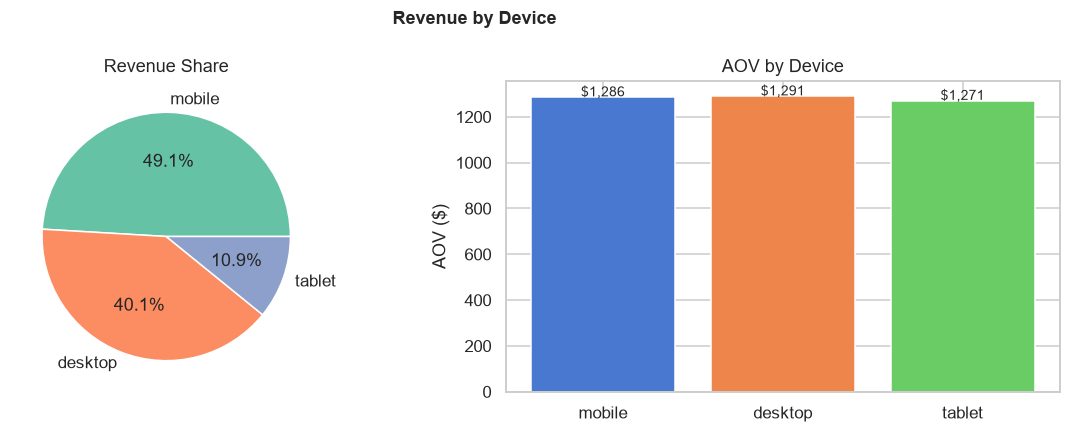

In [4]:
# Cell 4 — Revenue by Device Type
sql = """
SELECT s.device_type,
       COUNT(CASE WHEN o.status='completed' THEN 1 END)                            AS orders,
       ROUND(SUM(CASE WHEN o.status='completed' THEN o.total_amount ELSE 0 END),2) AS revenue,
       ROUND(AVG(CASE WHEN o.status='completed' THEN o.total_amount END),2)        AS aov
FROM orders o JOIN sessions s ON o.session_id=s.session_id
GROUP BY s.device_type ORDER BY revenue DESC
"""
df_device = pd.read_sql(sql, conn)
df_device['revenue_share_pct'] = (df_device['revenue'] / df_device['revenue'].sum() * 100).round(1)
print(df_device.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Revenue by Device', fontsize=12, fontweight='bold')

axes[0].pie(df_device['revenue'], labels=df_device['device_type'], autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3))
axes[0].set_title('Revenue Share')

axes[1].bar(df_device['device_type'], df_device['aov'],
            color=sns.color_palette('muted', 3))
axes[1].set_title('AOV by Device')
axes[1].set_ylabel('AOV ($)')
for i, v in enumerate(df_device['aov']):
    axes[1].text(i, v + 3, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_by_device.png', bbox_inches='tight')
plt.show()

  subcategory  orders  units_sold  gross_revenue  gross_profit  margin_pct
      Laptops     711         915     1383614.74     619544.56        44.8
  Smartphones     668         865      697233.56     333493.22        47.8
      Cameras     288         371      627400.30     260583.01        41.5
          TVs     264         323      394349.23     179919.07        45.6
      Tablets     381         482      325518.31     155601.82        47.8
   Headphones     571         724      250518.35     135689.65        54.2
Smart Watches     383         486      231860.06     115639.03        49.9
       Gaming     228         276      137210.87      63082.15        46.0
  Accessories     341         442       32466.70      18968.60        58.4


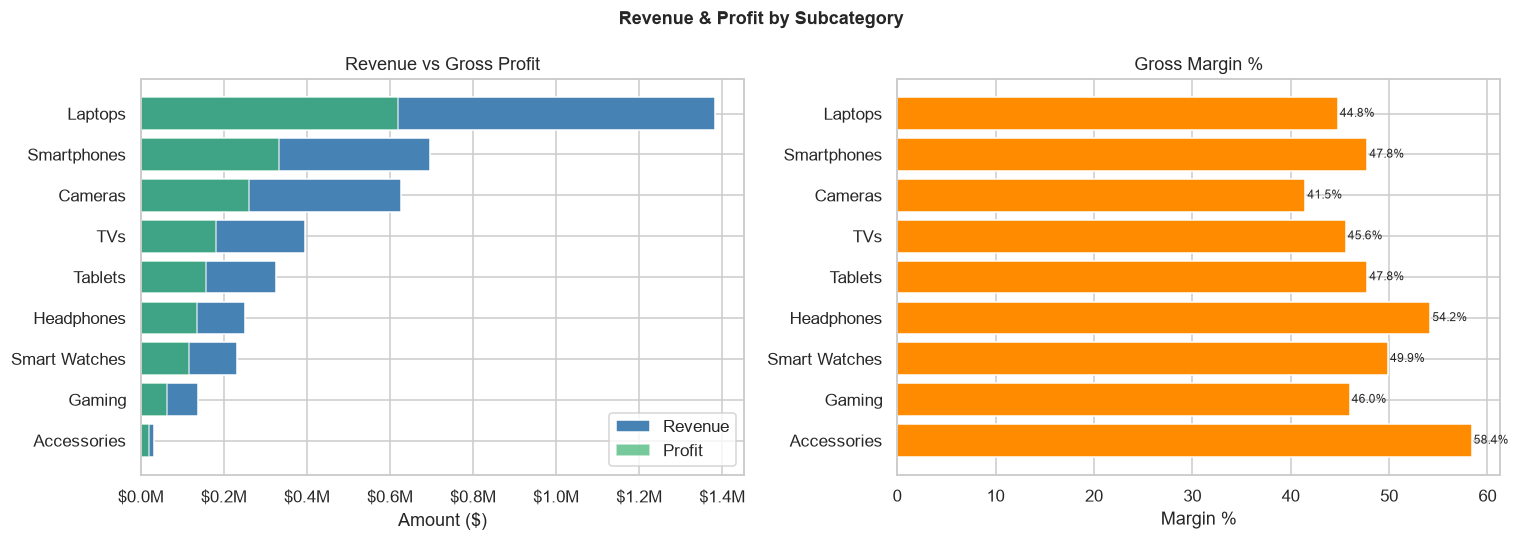

In [5]:
# Cell 5 — Revenue & Profit by Product Subcategory
sql = """
SELECT p.subcategory,
       COUNT(DISTINCT oi.order_id)                         AS orders,
       SUM(oi.quantity)                                    AS units_sold,
       ROUND(SUM(oi.quantity * oi.unit_price),2)           AS gross_revenue,
       ROUND(SUM(oi.quantity * (oi.unit_price - p.cost)),2) AS gross_profit
FROM order_items oi
JOIN products p ON oi.product_id=p.product_id
JOIN orders   o ON oi.order_id=o.order_id
WHERE o.status='completed'
GROUP BY p.subcategory ORDER BY gross_revenue DESC
"""
df_subcat = pd.read_sql(sql, conn)
df_subcat['margin_pct'] = (df_subcat['gross_profit'] / df_subcat['gross_revenue'] * 100).round(1)
print(df_subcat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue & Profit by Subcategory', fontsize=12, fontweight='bold')

subcat_sorted = df_subcat.sort_values('gross_revenue')
axes[0].barh(subcat_sorted['subcategory'], subcat_sorted['gross_revenue'],
             color='steelblue', label='Revenue')
axes[0].barh(subcat_sorted['subcategory'], subcat_sorted['gross_profit'],
             color='mediumseagreen', alpha=0.7, label='Profit')
axes[0].set_title('Revenue vs Gross Profit')
axes[0].set_xlabel('Amount ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].legend()

axes[1].barh(subcat_sorted['subcategory'], subcat_sorted['margin_pct'],
             color='darkorange')
axes[1].set_title('Gross Margin %')
axes[1].set_xlabel('Margin %')
for i, v in enumerate(subcat_sorted['margin_pct']):
    axes[1].text(v + 0.2, i, f'{v}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_by_subcategory.png', bbox_inches='tight')
plt.show()

           product_name subcategory  brand  orders  units_sold  total_revenue
     ThinkPad X1 Carbon     Laptops Lenovo      51          67      110210.00
ThinkPad X1 Carbon (v3)     Laptops Lenovo      40          53       95243.54
            XPS 15 (v3)     Laptops   Dell      36          56       95159.92
                 XPS 15     Laptops   Dell      44          52       93611.94
             Alpha 7 IV     Cameras   Sony      28          37       92128.22
            XPS 15 (v2)     Laptops   Dell      38          46       89155.69
           Spectre x360     Laptops     HP      42          58       86667.95
   OLED C3 65-inch (v2)         TVs     LG      36          47       82093.56
    MacBook Pro 14-inch     Laptops  Apple      34          40       80505.17
         EOS R6 Mark II     Cameras  Canon      26          32       79674.56


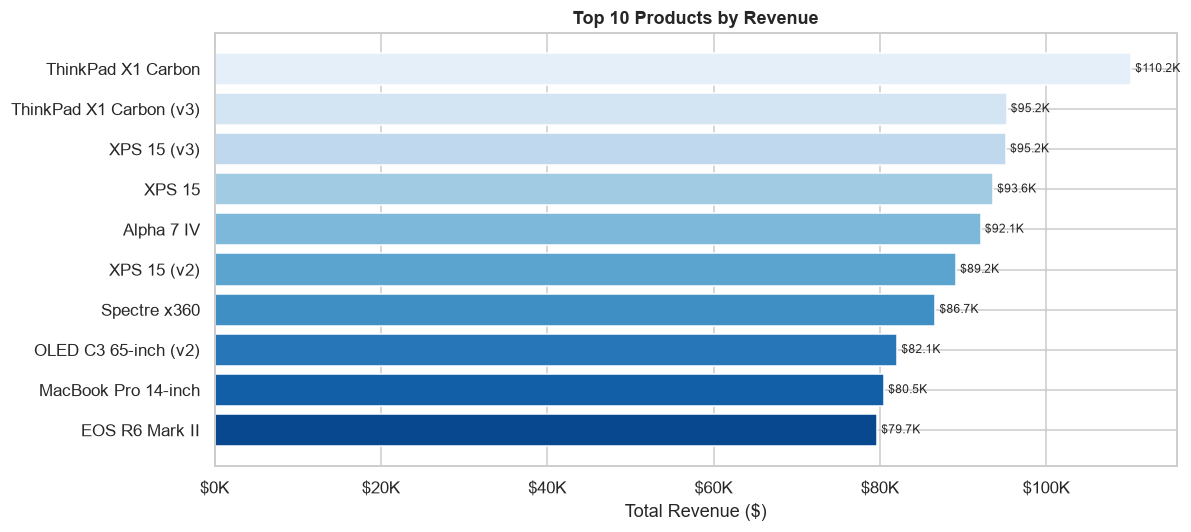

In [6]:
# Cell 6 — Top 10 Products by Revenue
sql = """
SELECT p.product_name, p.subcategory, p.brand,
       COUNT(DISTINCT oi.order_id)                AS orders,
       SUM(oi.quantity)                           AS units_sold,
       ROUND(SUM(oi.quantity * oi.unit_price),2)  AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id=p.product_id
JOIN orders   o ON oi.order_id=o.order_id
WHERE o.status='completed'
GROUP BY p.product_name, p.subcategory, p.brand
ORDER BY total_revenue DESC LIMIT 10
"""
df_top10 = pd.read_sql(sql, conn)
print(df_top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(df_top10['product_name'][::-1], df_top10['total_revenue'][::-1],
        color=sns.color_palette('Blues_r', 10))
ax.set_title('Top 10 Products by Revenue', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
for i, v in enumerate(df_top10['total_revenue'][::-1]):
    ax.text(v + 500, i, f'${v/1e3:.1f}K', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_top10_products.png', bbox_inches='tight')
plt.show()

discount_group  orders  avg_order_value  total_revenue  avg_discount
   No Discount    1701          1321.32     2247562.21           0.0
 With Discount    1440          1245.07     1792897.48          27.6


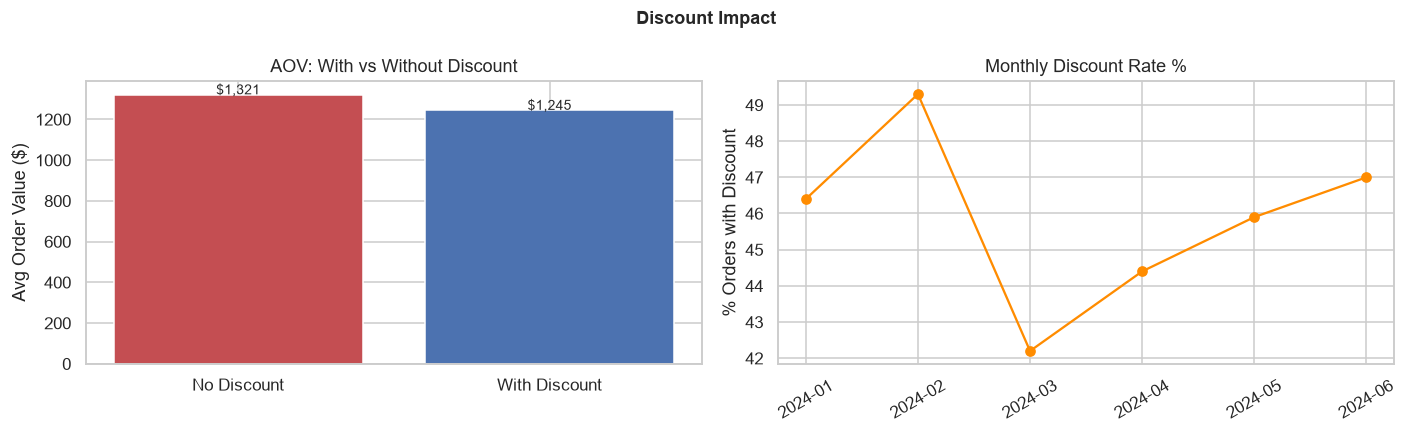

In [7]:
# Cell 7 — Discount Impact Analysis
sql = """
SELECT CASE WHEN discount_amount > 0 THEN 'With Discount' ELSE 'No Discount' END AS discount_group,
       COUNT(*)                     AS orders,
       ROUND(AVG(total_amount),2)   AS avg_order_value,
       ROUND(SUM(total_amount),2)   AS total_revenue,
       ROUND(AVG(discount_amount),2) AS avg_discount
FROM orders WHERE status='completed'
GROUP BY discount_group
"""
df_discount = pd.read_sql(sql, conn)
print(df_discount.to_string(index=False))

sql2 = """
SELECT strftime('%Y-%m', order_date) AS month,
       ROUND(100.0*COUNT(CASE WHEN discount_amount>0 THEN 1 END)/COUNT(*),1) AS discount_rate_pct,
       ROUND(SUM(discount_amount),0) AS total_discounts
FROM orders WHERE status='completed'
GROUP BY month ORDER BY month
"""
df_disc_trend = pd.read_sql(sql2, conn)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Discount Impact', fontsize=12, fontweight='bold')

x = range(len(df_discount))
axes[0].bar(df_discount['discount_group'], df_discount['avg_order_value'],
            color=['#C44E52','#4C72B0'])
axes[0].set_title('AOV: With vs Without Discount')
axes[0].set_ylabel('Avg Order Value ($)')
for i, v in enumerate(df_discount['avg_order_value']):
    axes[0].text(i, v + 2, f'${v:,.0f}', ha='center', fontsize=9)

axes[1].plot(df_disc_trend['month'], df_disc_trend['discount_rate_pct'],
             color='darkorange', marker='o')
axes[1].set_title('Monthly Discount Rate %')
axes[1].set_ylabel('% Orders with Discount')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_discount_impact.png', bbox_inches='tight')
plt.show()

Total buyers    : 2,198
One-time buyers : 1,501  (68.3%)
Repeat buyers   : 697  (31.7%)
Avg orders/user : 1.43


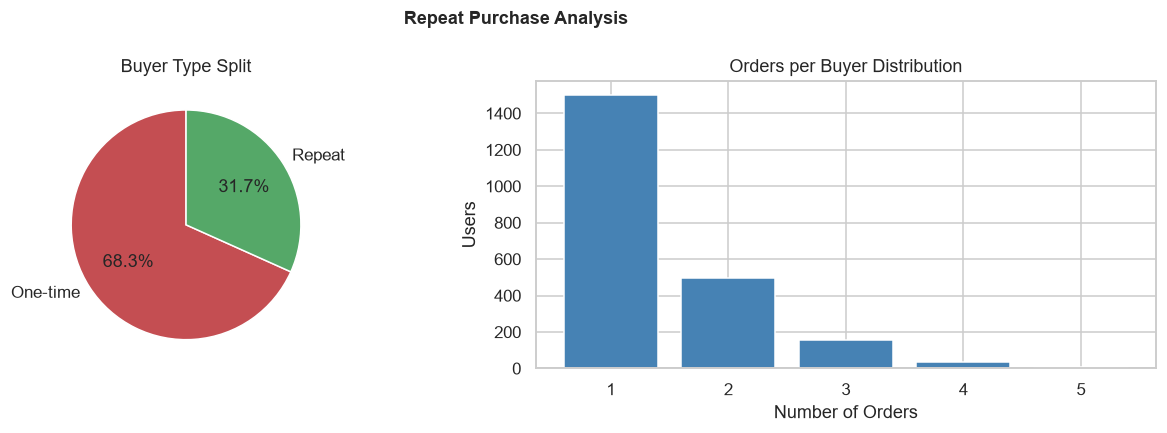

Done. All revenue charts saved.


In [8]:
# Cell 8 — Repeat Purchase Rate
sql = """
SELECT user_id, COUNT(*) AS order_count
FROM orders WHERE status='completed'
GROUP BY user_id
"""
df_uoc = pd.read_sql(sql, conn)

total_buyers   = len(df_uoc)
one_time       = (df_uoc['order_count'] == 1).sum()
repeat_buyers  = (df_uoc['order_count'] >= 2).sum()
repeat_rate    = repeat_buyers / total_buyers * 100

print(f'Total buyers    : {total_buyers:,}')
print(f'One-time buyers : {one_time:,}  ({one_time/total_buyers*100:.1f}%)')
print(f'Repeat buyers   : {repeat_buyers:,}  ({repeat_rate:.1f}%)')
print(f'Avg orders/user : {df_uoc["order_count"].mean():.2f}')

opu_dist = df_uoc['order_count'].value_counts().sort_index().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Repeat Purchase Analysis', fontsize=12, fontweight='bold')

axes[0].pie([one_time, repeat_buyers], labels=['One-time','Repeat'],
            autopct='%1.1f%%', colors=['#C44E52','#55A868'], startangle=90)
axes[0].set_title('Buyer Type Split')

axes[1].bar(opu_dist.index.astype(str), opu_dist.values, color='steelblue')
axes[1].set_title('Orders per Buyer Distribution')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Users')

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'revenue_repeat_purchase.png', bbox_inches='tight')
plt.show()

conn.close()
print('Done. All revenue charts saved.')

---
**Next:** Open `05_cohort_analysis.ipynb`